# 03 — Módulo B: modelo predictivo de riesgo académico

**Pregunta:** ¿qué estudiantes matriculados tienen mayor probabilidad de caer en
bajo rendimiento, para priorizar el acompañamiento de bienestar universitario?

**Definiciones**
* **Población**: 6.455 estudiantes con historia académica (se excluyen 1.702 de
  primer semestre, identificados por el centinela `9.99` en el promedio).
* **Target primario**: `PROMEDIO_PROGRAMA < 3.0` **o** haber estado en período de
  prueba (prevalencia 4,6%).
* **Sin fuga de información**: promedios, períodos de prueba y créditos aprobados
  se excluyen de las features; quedan 15 variables de perfil (sexo, edad, estrato,
  sede, facultad, tipo de aceptación, colegio de origen, antigüedad…) más el
  **contexto municipal** derivado del Módulo A (ruralidad, Saber 11 municipal y
  cobertura de acompañamiento del municipio de residencia).
* **Validación**: comparación por CV estratificada 5-fold (métrica principal
  PR-AUC por el desbalance) y evaluación final en un held-out del 20%.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import pandas as pd
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

In [2]:
import module_b
module_b.main()

Población: 6455 de 8157 matriculados (se excluyen 1702 sin historia académica)
Target primario (prom<3.0 o prueba): 4.6% (297 casos) | alternativo (rezago): 13.8%
Train: 5164 | Test (held-out): 1291
Validación cruzada (train):


  Regresión logística: ROC-AUC 0.874 | PR-AUC 0.321 | F1 0.292


  Random Forest: ROC-AUC 0.859 | PR-AUC 0.269 | F1 0.312


C:\Users\franc\PycharmProjects\pythonProject\Udea\MINTIC\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\franc\PycharmProjects\pythonProject\Udea\MINTIC\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\franc\PycharmProjects\pythonProject\Udea\MINTIC\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\franc\PycharmProjects\pythonProject\Udea\MINTIC\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

C:\Users\franc\PycharmProjects\pythonProject\Udea\MINTIC\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\franc\PycharmProjects\pythonProject\Udea\MINTIC\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM: ROC-AUC 0.849 | PR-AUC 0.277 | F1 0.258
Mejor modelo por PR-AUC: Regresión logística
Held-out — ROC-AUC 0.870 | PR-AUC 0.314 | F1@0.5 0.285
              precision    recall  f1-score   support

  sin riesgo       0.99      0.83      0.90      1232
      riesgo       0.18      0.76      0.28        59

    accuracy                           0.82      1291
   macro avg       0.58      0.80      0.59      1291
weighted avg       0.95      0.82      0.87      1291

Decil de mayor riesgo: captura 63% de los casos reales (lift 6.2x)


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


Sensibilidad (target rezago): ROC-AUC 0.979 | PR-AUC 0.865


Top 8 variables (|SHAP| medio):
                       variable  importancia_media_abs_shap
           ANTIGUEDAD_SEMESTRES                    1.192124
               NIVEL_PREGRADO_1                    0.759072
               NIVEL_PREGRADO_2                    0.543119
               NIVEL_PREGRADO_9                    0.467475
                      SEXO_FEME                    0.376502
              NIVEL_PREGRADO_10                    0.334391
FACULTAD_FACULTAD DE INGENIERIA                    0.297939
               NIVEL_PREGRADO_3                    0.285384
Módulo B completo -> outputs/


## Comparación de modelos

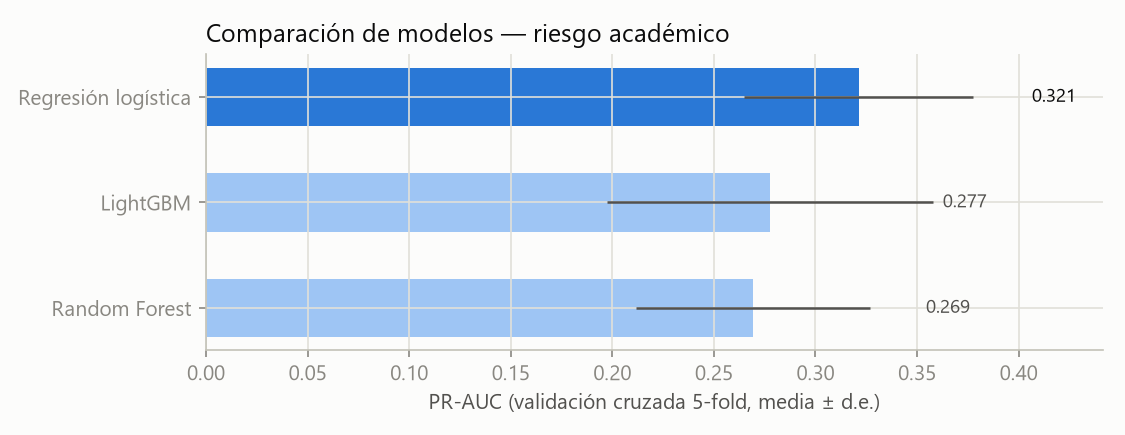

In [3]:
from IPython.display import Image
Image("../outputs/fig_comparacion_modelos.png")

In [4]:
pd.read_csv("../outputs/tabla_metricas.csv").round(3)

,modelo,cv_roc_auc,cv_roc_auc_std,cv_pr_auc,cv_pr_auc_std,cv_f1,heldout_roc_auc,heldout_pr_auc,heldout_f1
0,Regresión logística,0.874,0.018,0.321,0.056,0.292,0.87,0.314,0.285
1,Random Forest,0.859,0.012,0.269,0.058,0.312,NaN,NaN,NaN
2,LightGBM,0.849,0.022,0.277,0.080,0.258,NaN,NaN,NaN


Con solo ~300 positivos, la **regresión logística balanceada** supera a Random
Forest y LightGBM en PR-AUC — un resultado esperable: con pocas observaciones de
la clase minoritaria, los modelos de mayor capacidad no encuentran interacciones
que compensen su varianza. Se reporta igualmente la comparación completa.

## ¿Qué variables empujan el riesgo? (SHAP)

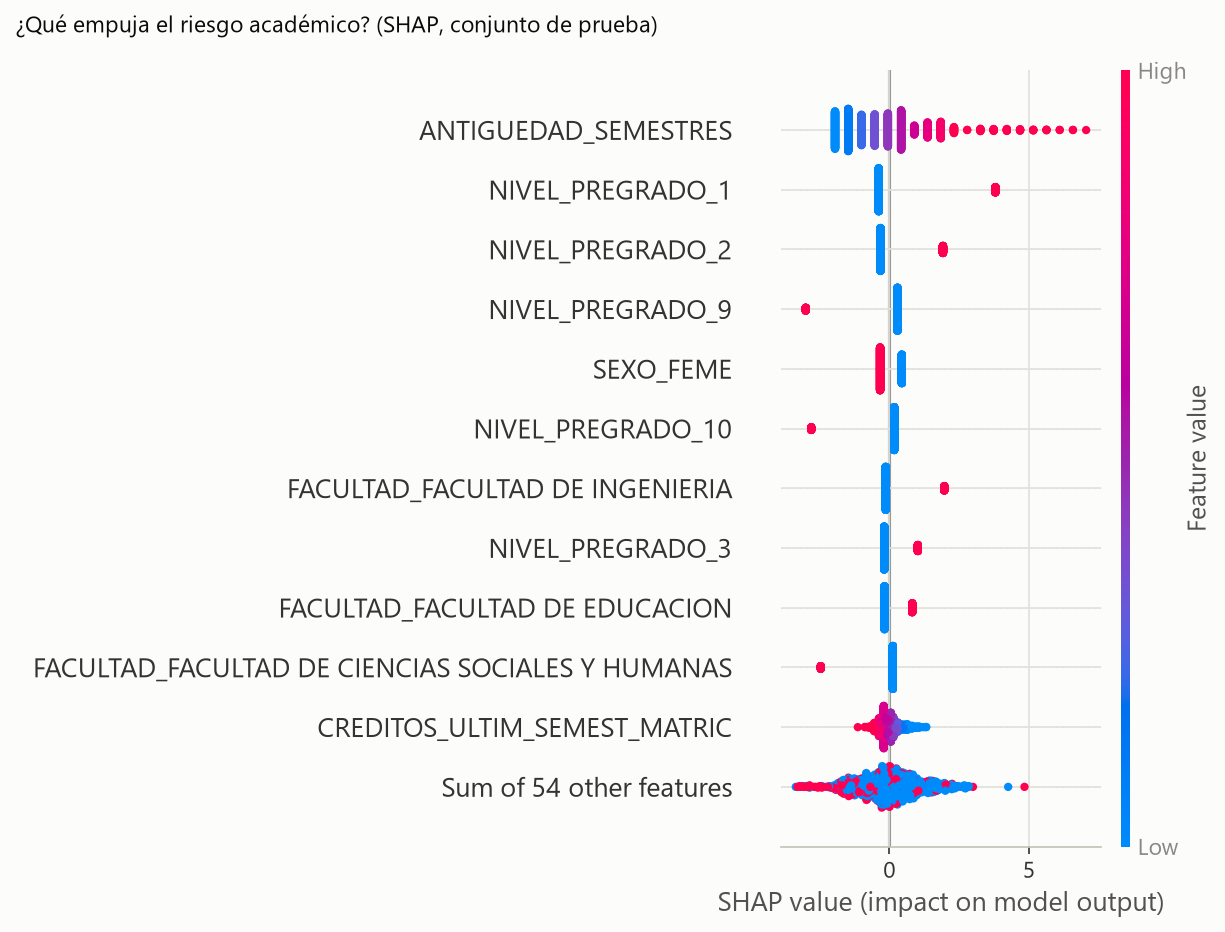

In [5]:
Image("../outputs/fig_shap_summary.png")

In [6]:
pd.read_csv("../outputs/importancia_shap.csv").head(12)

,variable,importancia_media_abs_shap
0,ANTIGUEDAD_SEMESTRES,1.192124
1,NIVEL_PREGRADO_1,0.759072
2,NIVEL_PREGRADO_2,0.543119
3,NIVEL_PREGRADO_9,0.467475
4,SEXO_FEME,0.376502
5,NIVEL_PREGRADO_10,0.334391
6,FACULTAD_FACULTAD DE INGENIERIA,0.297939
7,NIVEL_PREGRADO_3,0.285384
8,FACULTAD_FACULTAD DE EDUCACION,0.282148
9,FACULTAD_FACULTAD DE CIENCIAS SOCIALES Y HUMANAS,0.264216


**Lectura.**
* **Antigüedad sin avance de nivel** es el mayor factor de riesgo: estudiantes con
  muchos semestres de antigüedad que siguen en niveles 1-3.
* **Sexo**: ser mujer aparece como factor protector.
* **Facultad**: Ingeniería y Educación elevan el riesgo relativo.
* El **contexto municipal** (ruralidad, Saber 11 del municipio) aporta señal
  moderada: la brecha territorial también se expresa dentro del aula.

## Uso operativo (alerta temprana)

El **decil de mayor riesgo captura ~63% de los casos reales (lift 6,2×)**: con
capacidad de acompañar solo al 10% de la matrícula, bienestar universitario
concentraría dos tercios del riesgo real. `outputs/scoring_estudiantes.csv`
entrega la probabilidad y el decil por estudiante (anonimizado).

In [7]:
s = pd.read_csv("../outputs/scoring_estudiantes.csv")
print("distribución del scoring:")
print(s["PROB_RIESGO"].describe().round(3))
s.head(10)

distribución del scoring:
count    6455.000
mean        0.263
std         0.275
min         0.000
25%         0.059
50%         0.144
75%         0.400
max         1.000
Name: PROB_RIESGO, dtype: float64


,SEDE,FACULTAD,NOMBRE_MUNI_VIVE,PROGRAMA,PROB_RIESGO,DECIL_RIESGO
0,MEDELLIN,FACULTAD DE INGENIERIA,MEDELLIN,INGENIERIA DE SISTEMAS - REGION,1.0000,10
1,APARTADO,FACULTAD DE INGENIERIA,APARTADO,INGENIERIA CIVIL-APARTADO,0.9999,10
2,MEDELLIN,FACULTAD DE INGENIERIA,APARTADO,INGENIERIA INDUSTRIAL REGION,0.9999,10
3,MEDELLIN,FACULTAD DE INGENIERIA,TURBO,INGENIERIA DE SISTEMAS - REGION,0.9999,10
4,APARTADO,FACULTAD DE INGENIERIA,TURBO,INGENIERIA CIVIL-APARTADO,0.9999,10
5,CARMENVI,FACULTAD DE CIENCIAS EXACTAS Y NATURALES,LA CEJA,BIOLOGIA - CARMEN DE VIBORAL,0.9998,10
6,MEDELLIN,FACULTAD DE INGENIERIA,CHIGORODO,INGENIERIA AMBIENTAL REGION,0.9997,10
7,TURBO,FACULTAD DE CIENCIAS EXACTAS Y NATURALES,TURBO,ECOLOGIA DE ZONAS COSTERAS - TURBO,0.9997,10
8,MEDELLIN,FACULTAD DE INGENIERIA,TURBO,INGENIERIA DE SISTEMAS - REGION,0.9996,10
9,MEDELLIN,FACULTAD DE INGENIERIA,MARINILLA,INGENIERIA AMBIENTAL REGION,0.9993,10


## Análisis de sensibilidad y limitaciones

* Con el **target alternativo de rezago crediticio** el mismo pipeline alcanza
  ROC-AUC ≈ 0,98 — pero ese resultado está **parcialmente inflado**: la
  combinación antigüedad × nivel casi define el rezago, por lo que se reporta
  solo como sensibilidad y no como métrica principal.
* Los datos son un **corte transversal** (2026-1): el target refleja el estado
  acumulado, no deserción futura observada; un seguimiento longitudinal
  permitiría pasar de riesgo académico a predicción de deserción.
* El scoring debe usarse para **priorizar apoyo**, nunca para restringir acceso
  a servicios — el modelo hereda las desigualdades históricas del territorio.